# Support Vector Machines - SVM

---

Strong, useful and versatile algorithm used mainly for classification while regression is also possible.

### Classification

Idea: SVM tries to find the right *hyperplane* to distinguish all classed maximizing its distance  (*margin*) with the closest points (*support vectors*) of each class.

![visualization](https://assets.insightmediagroup.io/media/wp-content/uploads/2023/10/1bXlp7LVAPhIay-Pk0MxdlA.png)

Hyperparameter $C$:
- Large C: *Hard* margin requires zero classification mistakes. This works only if the data is linearly separable. Vulnerable to overfitting.
- Small C: *Soft* margin accepts a few classification mistakes to find a smoother line and generalize better. (regularization, less overfitting)

**Kernel Trick** (nonlinear SVM Classification):

Sometimes the data is not linearly separable. The kernel trick projects this into higher dimensions where it is linearly separable. 

kernel types:
- linear
- poly: using polynomial projections
- rbf: similarity features

Similarity Features:

Instead of training with the initial model features we create new ones based on their distance (*similarity*) with certain features of interest (*landmarks*).

**Gaussian RBF - Radial Basis Function**:

Can deal with very complex data.

RBF treats every instance of the dataset as a landmark. It measures their similarity K as: $$K \left(x , x^{'}\right) = exp \left(- \gamma \left\|x - x^{'}\right\|^{2}\right)$$

If two points are very similar $\left\|x - x^{'}\right\| \approx 0$ K is close to 1. If they're far apart it tends to zero.

Hyperparameter $\gamma$:

It controls the impact radius.
- Small γ: large radius -> smooth, simple border -> underfitting
- Large γ: small radius -> steep border -> overfitting

How to choose the right kernel:

We try first the linear kernel (`LinearSVC` because it is much faster than `SVC(kernel='linear')`) especially when the training set is very large. If it is not that large we try the RBF since it works in most cases. If we have time we experiment with other kernels using cross validation and grid search.

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

In [2]:
RANDOM_SEED = 42

BACKGROUND_COLOR = "lightgray"

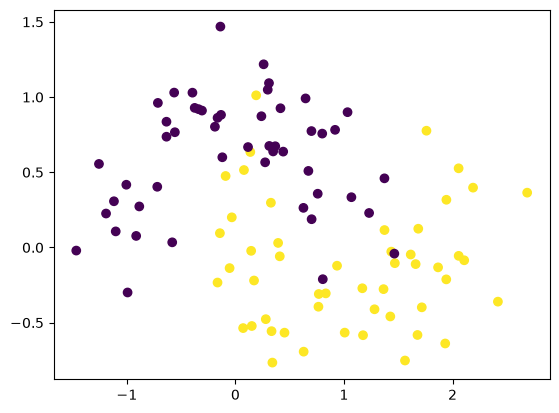

In [18]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=RANDOM_SEED)
plt.scatter(X[:, 0], X[:, 1], c=y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# small γ, by default c=1
rbf_smooth = SVC(kernel="rbf", gamma=0.1)
rbf_smooth.fit(X_train_scaled, y_train)

# large γ probable overfit
rbf_steep = SVC(kernel="rbf", gamma=10)
rbf_steep.fit(X_train_scaled, y_train)

y_pred_train_smooth = rbf_smooth.predict(X_train_scaled)
y_pred_train_steep = rbf_steep.predict(X_train_scaled)
y_pred_test_smooth = rbf_smooth.predict(X_test_scaled)
y_pred_test_steep = rbf_steep.predict(X_test_scaled)

print("Smooth model")
print(f"Train accuracy: {accuracy_score(y_train, y_pred_train_smooth)}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test_smooth)}")

print("Steep model")
print(f"Train accuracy: {accuracy_score(y_train, y_pred_train_steep)}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test_steep)}")

Smooth model
Train accuracy: 0.8125
Test accuracy: 1.0
Steep model
Train accuracy: 0.9625
Test accuracy: 0.8


We observe that the smooth model generalizes well and the steep overfits because the dataset is small and noisy. 

Reminder: in order to reduce overfit we can increase the test size or reduce the noise.

In order to find the right c, γ we use `GridSearchCV` to check all the possible combinations from our lists using cross validation.

**Coarse to fine** strategy:

First, we use logarithmic scale for both γ and C (exponential sensitivity) in order to find a good combination (coarse). After that, we use parameters close to the ones we found before to reach optimization (fine).

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
# Coarse Search

# we use data from above

# logarithmic scales for C, gamma (best practise)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "gamma": [0.01, 0.1, 1, 10],
    "kernel": ["rbf"],
}

svm_base = SVC(random_state=RANDOM_SEED)

# cv=5 -> 4 * 4 * 5 = 80 trainings
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,  # use all cpu cores
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best score during cv: {grid_search.best_score_:.4f}")

best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best score during cv: 0.9250
Test accuracy: 0.9500


In [22]:
# Fine Search

# Since best c and γ are 1 we search in [0.4, 2.0] for both

param_grid_fine = {
    "C": np.linspace(0.4, 2.0, num=9),
    "gamma": np.linspace(0.4, 2.0, num=9),
    "kernel": ["rbf"],
}

svm_base = SVC(random_state=RANDOM_SEED)

grid_search_fine = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_fine,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
)

grid_search_fine.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search_fine.best_params_}")
print(f"Best score during cv: {grid_search_fine.best_score_:.4f}")

best_fine_svm_model = grid_search_fine.best_estimator_
y_pred = best_fine_svm_model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Best params: {'C': np.float64(0.6000000000000001), 'gamma': np.float64(1.4), 'kernel': 'rbf'}
Best score during cv: 0.9375
Test accuracy: 1.0000


We observe that the fine search indeed optimized the parameters. Due to fact that the dataset is very small the split of train and test affects the accuracy a lot. Test accuracy of 1.0 is mostly luck. By increasing the dataset samples or changing the split's random state and tuning the fine search again if needed we can get a more logical test accuracy.

### Regression

Idea: We try to maximize the number of instances that belong in the line (or in general curve). Note that the curve has a width ($\epsilon$) meaning it is more like a tube.

![visualization](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*mr3tPTzUvwQ8FsetbRkjFA.png)

For every point inside the tube we consider zero error. For every point outside the tube we add error and consider it as a support vector. That's the reason SVR is called $\epsilon$-insensitive (insensitive to error inside the tube).

Hyperparameter $\epsilon$: "tube width"
- Small ε: too strict model -> more sv -> overfitting
- Large ε: simpler -> less sv -> underfitting

Just like in classification we have hyperparameter $C$ and kernel.

Why SVR over Linear/Polynomial regression:
- robust to outliers
- flexibility due to rbf kernel

In [23]:
from sklearn.svm import SVR

In [ ]:
# Coarse search

np.random.seed(RANDOM_SEED)
X = np.sort(np.random.rand(100, 1) * 6)
y = np.sin(X).ravel() + np.random.randn(100) * 0.1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# because we feed this grid in a pipeline we use the prefix: 'svr__'
param_grid = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__gamma": [0.01, 0.1, 1, 10],
    "svr__epsilon": [0.01, 0.05, 0.1, 0.2],
}

svr_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma=0.5)),
    ]
)

grid_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="r2",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score during cv: {grid_search.best_score_}")
print(f"Test R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")

Best parameters: {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 1}
Best score during cv: 0.9792176071051479
Test R-squared: 0.9878
Test MSE: 0.0075


Note: SVMs can be used for outlier detection (left for later)